# Energy Complete Experiment

Compact 20-seed real-data workflow for CMDL, plain LSTM, grouped ARDL, and AC-GATE ablations. The structure matches the other experiment notebooks: configure, optionally run, consolidate, audit, and visualize.

Run switches are off by default because the full 20-seed suite is intentionally expensive. Flip them to regenerate artifacts; otherwise the notebook reads existing outputs from `OUTPUT_ROOT`.


In [18]:
from argparse import Namespace
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next((path for path in [current, *current.parents] if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()), None)
if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import evaluation as evaluation_package

for module_name in ["evaluation.energy_comparison", "evaluation.economics_comparison"]:
    sys.modules.pop(module_name, None)
for attribute_name in ["energy_comparison", "economics_comparison"]:
    if hasattr(evaluation_package, attribute_name):
        delattr(evaluation_package, attribute_name)

from evaluation import energy_comparison as comparison_module
from experiments import run_energy as cmdl_module
from experiments import run_energy_lstm_baseline as baseline_module
from experiments import run_energy_grouped_ardl as grouped_ardl_module
from experiments import run_energy_ablation as ablation_module

cmdl_module = importlib.reload(cmdl_module)
baseline_module = importlib.reload(baseline_module)
grouped_ardl_module = importlib.reload(grouped_ardl_module)
ablation_module = importlib.reload(ablation_module)

build_comparison = comparison_module.build_energy_comparison
build_task_table = comparison_module.build_task_table
build_interpretability_table = comparison_module.build_interpretability_table
build_per_proxy_alignment_table = comparison_module.build_per_proxy_alignment_table
build_per_proxy_audit_summary_table = comparison_module.build_per_proxy_audit_summary_table
build_grouped_ardl_lag_trend_table = comparison_module.build_grouped_ardl_lag_trend_table
build_mechanism_summary_table = comparison_module.build_mechanism_summary_table
build_mechanism_result_log = comparison_module.build_mechanism_result_log
run_cmdl_experiment = cmdl_module.run_experiment
run_baseline_experiment = baseline_module.run_experiment
run_grouped_ardl_experiment = grouped_ardl_module.run_experiment
run_ablation_suite = ablation_module.run_suite

SEEDS = list(range(20))
RUN_CMDL = False
RUN_BASELINE = False
RUN_GROUPED_ARDL = False
RUN_ABLATIONS = False
ACTIVE_PLAN = "complete_20seed"
FALLBACK_PLAN = "multiseed_audit"

REQUESTED_OUTPUT_ROOT = repo_root / "outputs" / "notebook_energy" / ACTIVE_PLAN
FALLBACK_OUTPUT_ROOT = repo_root / "outputs" / "notebook_energy" / FALLBACK_PLAN
COMPARISON_DIR = REQUESTED_OUTPUT_ROOT / "comparison"
PLOTS_DIR = REQUESTED_OUTPUT_ROOT / "comparison_plots"

PRESET = {"epochs": 120, "patience": 20, "log_every": 10}
COMMON_ARGS = {
    "csv_path": str(repo_root / "data" / "energy" / "raw" / "energy_wgi_merged.csv"),
    "year_start": 1996,
    "year_end": 2023,
    "train_end_year": 2011,
    "val_end_year": 2017,
    "treatment_column": "renewables_share_energy",
    "target_column": "co2_per_unit_energy",
    "feature_bundle": "minimal",
    "grad_clip_mode": "global",
    "max_missing_share": 0.15,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "omega_transform": "softmax",
    "lambda_omega_entropy": 0.0,
    "omega_entropy_min": None,
    "omega_entropy_max": None,
    "lambda_z_anchor": 0.0,
    "z_anchor_target_sign": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "device": "auto",
    "disable_mlflow": True,
    "smoke": False,
}

def has_summary_artifacts(path: Path) -> bool:
    return path.exists() and any(path.glob("*/summary.json"))

RUN_ANY = RUN_CMDL or RUN_BASELINE or RUN_GROUPED_ARDL or RUN_ABLATIONS
REQUESTED_HAS_RESULTS = any(has_summary_artifacts(REQUESTED_OUTPUT_ROOT / name) for name in ["cmdl", "plain_lstm", "grouped_ardl", "ablation"])
FALLBACK_HAS_RESULTS = any(has_summary_artifacts(FALLBACK_OUTPUT_ROOT / name) for name in ["cmdl", "plain_lstm", "grouped_ardl", "ablation"])
USE_FALLBACK_ARTIFACTS = (not RUN_ANY) and (not REQUESTED_HAS_RESULTS) and FALLBACK_HAS_RESULTS
ARTIFACT_ROOT = FALLBACK_OUTPUT_ROOT if USE_FALLBACK_ARTIFACTS else REQUESTED_OUTPUT_ROOT
ARTIFACT_SOURCE = FALLBACK_PLAN if USE_FALLBACK_ARTIFACTS else ACTIVE_PLAN

OUTPUT_ROOT = REQUESTED_OUTPUT_ROOT
CMDL_DIR = ARTIFACT_ROOT / "cmdl"
BASELINE_DIR = ARTIFACT_ROOT / "plain_lstm"
GROUPED_ARDL_DIR = ARTIFACT_ROOT / "grouped_ardl"
ABLATION_DIR = ARTIFACT_ROOT / "ablation"

for path in [REQUESTED_OUTPUT_ROOT, REQUESTED_OUTPUT_ROOT / "cmdl", REQUESTED_OUTPUT_ROOT / "plain_lstm", REQUESTED_OUTPUT_ROOT / "grouped_ardl", REQUESTED_OUTPUT_ROOT / "ablation", COMPARISON_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

settings = pd.Series(
    {
        "active_plan": ACTIVE_PLAN,
        "artifact_source": ARTIFACT_SOURCE,
        "seed_count_planned": len(SEEDS),
        "seeds_planned": SEEDS,
        "requested_output_root": REQUESTED_OUTPUT_ROOT,
        "artifact_root_resolved": ARTIFACT_ROOT,
        **PRESET,
        **COMMON_ARGS,
    },
    name="value",
).to_frame()
display(settings)

,value
active_plan,complete_20seed
artifact_source,complete_20seed
seed_count_planned,20
seeds_planned,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
requested_output_root,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
artifact_root_resolved,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
epochs,120
patience,20
log_every,10
csv_path,C:\DevSpace\PyDevspace\CMDL\data\energy\raw\en...


In [19]:
cmdl_summaries = []
baseline_summaries = []
grouped_ardl_summaries = []
ablation_summary_frame = pd.DataFrame()
ablation_aggregated_frame = pd.DataFrame()

for seed in SEEDS:
    shared_args = {**COMMON_ARGS, **PRESET, "seed": seed}
    if RUN_CMDL:
        cmdl_summaries.append(run_cmdl_experiment(Namespace(**shared_args, output_dir=str(CMDL_DIR), experiment_name=f"energy_cmdl_seed{seed}")))
    if RUN_BASELINE:
        baseline_summaries.append(run_baseline_experiment(Namespace(**shared_args, output_dir=str(BASELINE_DIR), experiment_name=f"energy_lstm_seed{seed}")))
    if RUN_GROUPED_ARDL:
        grouped_ardl_summaries.append(run_grouped_ardl_experiment(Namespace(**shared_args, output_dir=str(GROUPED_ARDL_DIR), experiment_name=f"energy_grouped_ardl_seed{seed}")))

if RUN_ABLATIONS:
    ablation_args = Namespace(**COMMON_ARGS, **PRESET, variant="all", seeds=SEEDS, output_dir=str(ABLATION_DIR), experiment_prefix="energy_ablation")
    ablation_summary_frame, ablation_aggregated_frame = run_ablation_suite(ablation_args)
else:
    print("Run switches are off; using existing artifacts if present.")


Run switches are off; using existing artifacts if present.


In [20]:
def compact_realdata_summary(frame: pd.DataFrame) -> pd.DataFrame:
    columns = [
        "display_name", "family", "variant", "target_column", "feature_bundle", "n_seeds",
        "test_r2_mean", "test_r2_std", "anchor_adjusted_rho_mean", "anchor_positive_seed_share",
        "mean_proxy_adjusted_rho_mean", "mean_proxy_positive_seed_share", "kstar_std_mean",
        "entropy_mean", "lag_gate_sensitivity_range_mean", "proxy_signal_r2_mean",
    ]
    if frame.empty:
        return pd.DataFrame(columns=columns)
    rows = []
    for keys, group in frame.groupby(["display_name", "family", "variant", "target_column", "feature_bundle"], dropna=False):
        display_name, family, variant, target_column, feature_bundle = keys
        adjusted = pd.to_numeric(group.get("test_effective_kstar_proxy_spearman_adjusted_rho"), errors="coerce")
        mean_adjusted = pd.to_numeric(group.get("test_effective_kstar_proxy_mean_spearman_adjusted_rho"), errors="coerce")
        r2 = pd.to_numeric(group.get("test_r2"), errors="coerce")
        kstd = pd.to_numeric(group.get("test_effective_kstar_std"), errors="coerce")
        proxy_signal = pd.to_numeric(group.get("test_proxy_signal_r2"), errors="coerce")
        entropy = pd.to_numeric(group.get("test_effective_lag_entropy_mean"), errors="coerce")
        lag_range = pd.to_numeric(group.get("test_lag_gate_sensitivity_range"), errors="coerce")
        rows.append({
            "display_name": display_name,
            "family": family,
            "variant": variant,
            "target_column": target_column,
            "feature_bundle": feature_bundle,
            "n_seeds": int(group["seed"].nunique(dropna=True)),
            "test_r2_mean": r2.mean(skipna=True),
            "test_r2_std": r2.std(skipna=True),
            "anchor_adjusted_rho_mean": adjusted.mean(skipna=True),
            "anchor_positive_seed_share": float((adjusted.dropna() > 0).mean()) if not adjusted.dropna().empty else np.nan,
            "mean_proxy_adjusted_rho_mean": mean_adjusted.mean(skipna=True),
            "mean_proxy_positive_seed_share": float((mean_adjusted.dropna() > 0).mean()) if not mean_adjusted.dropna().empty else np.nan,
            "kstar_std_mean": kstd.mean(skipna=True),
            "entropy_mean": entropy.mean(skipna=True),
            "lag_gate_sensitivity_range_mean": lag_range.mean(skipna=True),
            "proxy_signal_r2_mean": proxy_signal.mean(skipna=True),
        })
    return pd.DataFrame(rows, columns=columns).sort_values(["family", "display_name", "variant"], na_position="last").reset_index(drop=True)

comparison = build_comparison(cmdl_root=CMDL_DIR, baseline_root=BASELINE_DIR, ablation_root=ABLATION_DIR, grouped_ardl_root=GROUPED_ARDL_DIR)
task_table = build_task_table(comparison)
interpretability_table = build_interpretability_table(comparison)
per_proxy_table = build_per_proxy_alignment_table(comparison)
per_proxy_audit_summary = build_per_proxy_audit_summary_table(comparison)
grouped_ardl_lag_trend = build_grouped_ardl_lag_trend_table(comparison)
mechanism_summary = build_mechanism_summary_table(comparison)
result_log = build_mechanism_result_log(comparison)
compact_summary = compact_realdata_summary(comparison)

exports = {
    "energy_comparison.csv": comparison,
    "energy_task_table.csv": task_table,
    "energy_interpretability_table.csv": interpretability_table,
    "energy_per_proxy_adjusted_rho.csv": per_proxy_table,
    "energy_per_proxy_audit_summary.csv": per_proxy_audit_summary,
    "energy_grouped_ardl_lag_trend.csv": grouped_ardl_lag_trend,
    "energy_mechanism_summary.csv": mechanism_summary,
    "energy_result_log.csv": result_log,
    "energy_compact_summary.csv": compact_summary,
}
for name, frame in exports.items():
    frame.to_csv(COMPARISON_DIR / name, index=False)

print(f"comparison rows = {len(comparison)}")
display(compact_summary)
display(result_log)


comparison rows = 120


,display_name,family,variant,target_column,feature_bundle,n_seeds,test_r2_mean,test_r2_std,anchor_adjusted_rho_mean,anchor_positive_seed_share,mean_proxy_adjusted_rho_mean,mean_proxy_positive_seed_share,kstar_std_mean,entropy_mean,lag_gate_sensitivity_range_mean,proxy_signal_r2_mean
0,No AC Encoder,ablation,no_ac_encoder,co2_per_unit_energy,minimal,20,-0.026841,8.651686e-03,0.000000,0.00,0.000000,0.00,1.013279e-07,1.809857,0.000000,NaN
1,No Recon Regularization,ablation,no_recon_regularization,co2_per_unit_energy,minimal,20,-0.028494,4.984279e-03,0.001460,0.45,0.001393,0.45,1.101686e-01,1.858754,0.274014,0.698529
2,Uniform Lag,ablation,uniform_lag,co2_per_unit_energy,minimal,20,-0.029501,4.346215e-03,NaN,NaN,NaN,NaN,0.000000e+00,2.302585,0.426587,0.749979
3,CMDL,cmdl,NaN,co2_per_unit_energy,minimal,20,-0.028494,4.984665e-03,0.001398,0.45,0.001319,0.45,1.101681e-01,1.858755,0.274016,0.698519
4,Grouped ARDL,grouped_ardl,NaN,co2_per_unit_energy,minimal,20,0.607078,1.139065e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Plain LSTM,plain_lstm,NaN,co2_per_unit_energy,minimal,20,-0.028813,4.308463e-03,0.106561,0.80,0.103141,0.75,1.327178e+00,2.060541,NaN,NaN


,layer,question,answer,evidence
0,forecast_calibration,Does CMDL beat the matched LSTM?,yes,"mean CMDL test_r2=-0.028494254634130727, mean ..."
1,simple_baseline_calibration,Is CMDL above the simple calibrated baselines?,no,"delta_vs_persistence=-0.7873333097615072, delt..."
2,ac_gate_mechanism,Does the anchor-adjusted lag-proxy direction s...,partial,"CMDL mean adjusted rho=0.0013984405768328934, ..."
3,ac_gate_per_proxy,Are all named proxy adjusted correlations alig...,no,"candidate_positive_proxies=0/3, min_adjusted_r..."
4,ac_gate_heterogeneity,Is the learned lag gate non-degenerate?,yes,"lag_gate_sensitivity_range=0.2740158438682556,..."
5,ablation_guard,Do degenerate controls expose the heterogeneit...,yes,"No AC kstar_std=1.0132789611816406e-07, Unifor..."


,display_name,family,variant,seed,experiment,target_column,feature_bundle,best_epoch,best_val_task_loss,test_r2,test_baseline_persistence_r2,test_baseline_panel_ols_r2,test_baseline_grouped_ardl_r2,test_baseline_best_simple_r2,test_r2_delta_vs_persistence,test_r2_delta_vs_panel_ols,test_r2_delta_vs_grouped_ardl,test_mae,test_mse
0,Grouped ARDL,grouped_ardl,None,0,energy_grouped_ardl_seed0,co2_per_unit_energy,minimal,0,8.610673,0.607078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.809800,14725.707788
1,Grouped ARDL,grouped_ardl,None,1,energy_grouped_ardl_seed1,co2_per_unit_energy,minimal,0,8.610673,0.607078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.809800,14725.707788
2,Grouped ARDL,grouped_ardl,None,2,energy_grouped_ardl_seed2,co2_per_unit_energy,minimal,0,8.610673,0.607078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.809800,14725.707788
3,Grouped ARDL,grouped_ardl,None,3,energy_grouped_ardl_seed3,co2_per_unit_energy,minimal,0,8.610673,0.607078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.809800,14725.707788
4,Grouped ARDL,grouped_ardl,None,4,energy_grouped_ardl_seed4,co2_per_unit_energy,minimal,0,8.610673,0.607078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.809800,14725.707788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,No Recon Regularization,ablation,no_recon_regularization,3,energy_ablation_no_recon_regularization_seed3,co2_per_unit_energy,minimal,20,15.436889,-0.038186,0.758839,0.63286,0.607078,0.758839,-0.797025,-0.671046,-0.645264,17.075375,24219.475507
116,CMDL,cmdl,None,3,energy_cmdl_seed3,co2_per_unit_energy,minimal,20,15.437041,-0.038188,0.758839,0.63286,0.607078,0.758839,-0.797027,-0.671047,-0.645266,17.075402,24219.478178
117,Uniform Lag,ablation,uniform_lag,5,energy_ablation_uniform_lag_seed5,co2_per_unit_energy,minimal,18,15.545711,-0.038506,0.758839,0.63286,0.607078,0.758839,-0.797345,-0.671366,-0.645584,17.237593,24217.587884
118,No AC Encoder,ablation,no_ac_encoder,15,energy_ablation_no_ac_encoder_seed15,co2_per_unit_energy,minimal,19,15.689580,-0.041723,0.758839,0.63286,0.607078,0.758839,-0.800562,-0.674583,-0.648801,17.375179,24234.296325


,display_name,family,variant,seed,experiment,target_column,feature_bundle,lag_method,anchor_proxy_name,anchor_expected_sign,...,test_lag_gate_sensitivity_slope,test_lag_gate_sensitivity_range,test_proxy_signal_r2,test_proxy_signal_metric_valid,omega_transform,lambda_omega_entropy,omega_entropy_min,omega_entropy_max,lambda_z_anchor,z_anchor_target_sign
0,No Recon Regularization,ablation,no_recon_regularization,7,energy_ablation_no_recon_regularization_seed7,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,0.627970,0.321527,0.844133,True,softmax,0.0,None,None,0.0,1.0
1,CMDL,cmdl,None,7,energy_cmdl_seed7,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,0.627946,0.321509,0.844125,True,softmax,0.0,None,None,0.0,1.0
2,CMDL,cmdl,None,13,energy_cmdl_seed13,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,0.559803,0.335165,0.858764,True,softmax,0.0,None,None,0.0,1.0
3,No Recon Regularization,ablation,no_recon_regularization,13,energy_ablation_no_recon_regularization_seed13,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,0.559803,0.335170,0.858760,True,softmax,0.0,None,None,0.0,1.0
4,No Recon Regularization,ablation,no_recon_regularization,9,energy_ablation_no_recon_regularization_seed9,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,0.596996,0.415640,0.820294,True,softmax,0.0,None,None,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,No AC Encoder,ablation,no_ac_encoder,13,energy_ablation_no_ac_encoder_seed13,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0
116,No AC Encoder,ablation,no_ac_encoder,14,energy_ablation_no_ac_encoder_seed14,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0
117,No AC Encoder,ablation,no_ac_encoder,16,energy_ablation_no_ac_encoder_seed16,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0
118,No AC Encoder,ablation,no_ac_encoder,17,energy_ablation_no_ac_encoder_seed17,co2_per_unit_energy,minimal,learned_omega,proxy_government_effectiveness,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0


,display_name,family,variant,target_column,feature_bundle,anchor_proxy_name,proxy_index,proxy_name,expected_sign,n_seeds,n_valid,rho_mean,rho_std,adjusted_rho_mean,adjusted_rho_std,adjusted_rho_min,adjusted_rho_max,positive_seed_share,p_value_median,mechanism_status
0,CMDL,cmdl,NaN,co2_per_unit_energy,minimal,proxy_government_effectiveness,1,government_effectiveness,-1.0,20,20,-0.001398,0.788029,0.001398,0.788029,-0.935533,0.956980,0.45,6.585839e-21,mixed_or_negative
1,CMDL,cmdl,NaN,co2_per_unit_energy,minimal,proxy_government_effectiveness,2,regulatory_quality,-1.0,20,20,-0.016228,0.784947,0.016228,0.784947,-0.897090,0.968361,0.45,4.552200e-16,mixed_or_negative
2,CMDL,cmdl,NaN,co2_per_unit_energy,minimal,proxy_government_effectiveness,3,rule_of_law,-1.0,20,20,0.011964,0.796993,-0.011964,0.796993,-0.949317,0.951618,0.45,1.535790e-18,mixed_or_negative


,display_name,family,seed,experiment,target_column,feature_bundle,anchor_proxy_name,anchor_expected_sign,group,group_order,best_lag,effective_lag,deterministic_baseline
0,Grouped ARDL,grouped_ardl,0,energy_grouped_ardl_seed0,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,low,1,8.0,6.622560,True
1,Grouped ARDL,grouped_ardl,0,energy_grouped_ardl_seed0,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,mid,2,4.0,4.866275,True
2,Grouped ARDL,grouped_ardl,0,energy_grouped_ardl_seed0,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,high,3,9.0,6.480639,True
3,Grouped ARDL,grouped_ardl,1,energy_grouped_ardl_seed1,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,low,1,8.0,6.622560,True
4,Grouped ARDL,grouped_ardl,1,energy_grouped_ardl_seed1,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,mid,2,4.0,4.866275,True
5,Grouped ARDL,grouped_ardl,1,energy_grouped_ardl_seed1,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,high,3,9.0,6.480639,True
6,Grouped ARDL,grouped_ardl,2,energy_grouped_ardl_seed2,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,low,1,8.0,6.622560,True
7,Grouped ARDL,grouped_ardl,2,energy_grouped_ardl_seed2,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,mid,2,4.0,4.866275,True
8,Grouped ARDL,grouped_ardl,2,energy_grouped_ardl_seed2,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,high,3,9.0,6.480639,True
9,Grouped ARDL,grouped_ardl,3,energy_grouped_ardl_seed3,co2_per_unit_energy,minimal,proxy_government_effectiveness,-1.0,low,1,8.0,6.622560,True


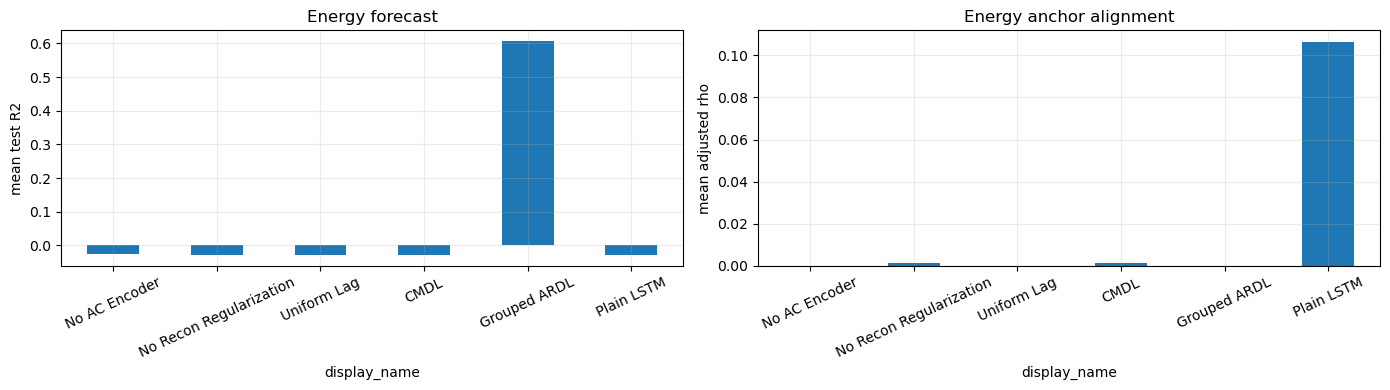

Saved plot to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_energy\complete_20seed\comparison_plots\energy_multiseed_summary.png


In [21]:
if comparison.empty:
    print("No energy artifacts found yet. Enable run switches or point OUTPUT_ROOT to an existing run directory.")
else:
    display(task_table)
    display(interpretability_table)
    display(per_proxy_audit_summary)
    display(grouped_ardl_lag_trend)
    plot_frame = compact_summary.copy()
    if not plot_frame.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_frame.plot(x="display_name", y="test_r2_mean", kind="bar", ax=axes[0], legend=False)
        axes[0].set_title("Energy forecast")
        axes[0].set_ylabel("mean test R2")
        axes[0].tick_params(axis="x", rotation=25)
        axes[0].grid(alpha=0.25)
        plot_frame.plot(x="display_name", y="anchor_adjusted_rho_mean", kind="bar", ax=axes[1], legend=False)
        axes[1].set_title("Energy anchor alignment")
        axes[1].set_ylabel("mean adjusted rho")
        axes[1].tick_params(axis="x", rotation=25)
        axes[1].grid(alpha=0.25)
        fig.tight_layout()
        plot_path = PLOTS_DIR / "energy_multiseed_summary.png"
        fig.savefig(plot_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved plot to {plot_path}")
